# Motor Imagery - Classification pipeline
**Models:** 

- Approach 1: ERD(Cz,C3,C4)+MRCP(Cz,Fz)
- Approach 2: ERD(Cz,C3,C4)+MRCP(Cz,Fz,C3,C4)
- CSP Cascade: 3 channels / 8 channels (ERD band / µ / β / µ+β)

**Validation strategies:**
- Within-subject: 80/20 stratified split per subject = individual performance
- LOSO (Leave-One-Subject-Out): train on 10 subjects, test on 1 = cross-subject generalisation

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import time, copy
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from mne.decoding import CSP

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')

## 1. Load data

In [2]:
# Model 1 and 2 features (ERD + MRCP)
df1 = pd.read_csv('features_model1_all.csv')
df2 = pd.read_csv('features_model2_all.csv')

print('Approach 1 shape:', df1.shape)
print('Approach 2 shape:', df2.shape)
print('Subjects found:', sorted(df1['subject'].unique()))
print('Class distribution:\n', df1['label'].value_counts())

Approach 1 shape: (3800, 18)
Approach 2 shape: (3800, 26)
Subjects found: ['v01', 'v02', 'v03', 'v04', 'v05', 'v06', 'v07', 'v08', 'v09', 'v10', 'v11']
Class distribution:
 label
right    1293
left     1267
rest     1240
Name: count, dtype: int64


In [3]:
# CSP trials
mat = scipy.io.loadmat('trials_CSP_all.mat')

# (n_trials, n_channels, n_samples)  after transpose
X_3ch      = np.transpose(mat['all_X3ch'],(2, 0, 1))
X_8ch      = np.transpose(mat['all_X8ch'],(2, 0, 1))
X_3ch_mu   = np.transpose(mat['all_X3ch_mu'],(2, 0, 1))
X_3ch_beta = np.transpose(mat['all_X3ch_beta'],(2, 0, 1))
X_8ch_mu   = np.transpose(mat['all_X8ch_mu'],(2, 0, 1))
X_8ch_beta = np.transpose(mat['all_X8ch_beta'],(2, 0, 1))

y_csp = mat['all_y_csp'].ravel() # -1 left / 0 rest / 1 right
groups_csp = mat['all_subj_csp'].ravel() # subject index 

# Mu+beta concatenation
X_3ch_mubeta = np.concatenate([X_3ch_mu, X_3ch_beta], axis=1)
X_8ch_mubeta = np.concatenate([X_8ch_mu, X_8ch_beta], axis=1)


## 2. Preprocessing helpers

In [4]:
# Encode labels
def encode_labels(y_str):
    
    le = LabelEncoder()
    return le.fit_transform(y_str), le

# Extract features, labels and subjects
def extract_Xy(df):
    
    feature_cols = [c for c in df.columns if c not in ('label', 'subject')]
    X       = df[feature_cols].values
    y       = df['label'].values
    groups  = df['subject'].values
    return X, y, groups

# Normalize csp
def normalise_csp(X):
    
    std = np.std(X, axis=2, keepdims=True)
    std[std == 0] = 1
    return X / std

# Models for flat features (Approach 1 and Approach 2)
def build_models_flat():
    
    return {
        'LDA': LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
        'LDA+PCA': Pipeline([
            ('pca', PCA(n_components=0.95)),
            ('lda', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
        ]),
        'SVM': SVC(kernel='rbf', C=1, gamma=0.1,
                   class_weight='balanced', random_state=RANDOM_STATE),
        'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced',
                                     random_state=RANDOM_STATE),
        'RF': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    }

# Models for cascade csp
def build_models_csp(n_comp=8):
    
    return {
        'CSP+LDA': Pipeline([
            ('csp', CSP(n_components=n_comp, reg='ledoit_wolf', log=False)),
            ('lda', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
        ]),
        'CSP+SVM': Pipeline([
            ('csp',    CSP(n_components=n_comp, reg='ledoit_wolf', log=False)),
            ('scaler', StandardScaler()),
            ('svm',    SVC(kernel='rbf', C=1, gamma=0.1, class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'CSP+LogReg': Pipeline([
            ('csp',    CSP(n_components=n_comp, reg='ledoit_wolf', log=False)),
            ('scaler', StandardScaler()),
            ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'CSP+LDA+FS': Pipeline([
            ('csp',    CSP(n_components=n_comp, reg='ledoit_wolf', log=False)),
            ('select', SelectKBest(f_classif, k=4)),
            ('lda',    LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
        ]),
    }

## 3. Within-subject evaluation: flat features (Approach 1 & 2)

For each subject: stratified 80/20 split  
Results are averaged across subjects per model.

In [5]:
def within_subject_flat(df, model_name_prefix=''):

    X, y_str, groups = extract_Xy(df)
    subjects = np.unique(groups)
    models = build_models_flat()
    records = []

    for subj in subjects:
        mask = groups == subj
        X_s, y_s = X[mask], y_str[mask]
        y_enc, le = encode_labels(y_s)

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_s, y_enc, test_size=0.2,
            stratify=y_enc, random_state=RANDOM_STATE
        )

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        for name, model in models.items():
            m = copy.deepcopy(model)
            m.fit(X_tr, y_tr)
            acc = accuracy_score(y_te, m.predict(X_te))
            records.append({'subject': subj,'model': f'{model_name_prefix}{name}','accuracy': acc})

    return pd.DataFrame(records)


print('Running within-subject: Approach 1')
ws_m1 = within_subject_flat(df1, 'A1_')

print('Running within-subject: Approach 2')
ws_m2 = within_subject_flat(df2, 'A2_')

ws_flat = pd.concat([ws_m1, ws_m2], ignore_index=True)

print('\nWithin-subject mean accuracy per model:')
print(ws_flat.groupby('model')['accuracy'].agg(['mean','std']).round(3))

Running within-subject: Approach 1
Running within-subject: Approach 2

Within-subject mean accuracy per model:
             mean    std
model                   
A1_LDA      0.466  0.084
A1_LDA+PCA  0.461  0.082
A1_LogReg   0.458  0.089
A1_RF       0.436  0.094
A1_SVM      0.446  0.079
A2_LDA      0.483  0.086
A2_LDA+PCA  0.472  0.101
A2_LogReg   0.484  0.099
A2_RF       0.442  0.091
A2_SVM      0.449  0.080


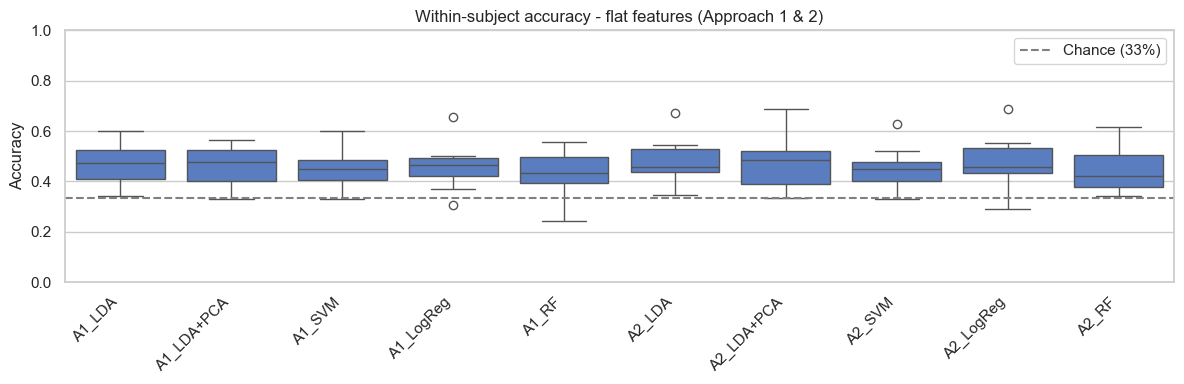

In [6]:
# Within-subject boxplot (all models)
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=ws_flat, x='model', y='accuracy', ax=ax)
ax.axhline(1/3, ls='--', color='gray', label='Chance (33%)')
ax.set_title('Within-subject accuracy - flat features (Approach 1 & 2)')
ax.set_xlabel('')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 4. LOSO evaluation: flat features (Approach 1 & 2)

In [7]:
def loso_flat(df, model_name_prefix=''):

    X, y_str, groups = extract_Xy(df)
    y_enc, le = encode_labels(y_str)
    logo = LeaveOneGroupOut()
    models = build_models_flat()
    records = []
    subject_list = np.unique(groups)

    for train_idx, test_idx in logo.split(X, y_enc, groups):
        left_out = groups[test_idx][0]

        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y_enc[train_idx], y_enc[test_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr) # fit on train only
        X_te   = scaler.transform(X_te)

        for name, model in models.items():
            import copy
            m = copy.deepcopy(model)
            m.fit(X_tr, y_tr)
            acc = accuracy_score(y_te, m.predict(X_te))
            records.append({'subject': left_out,'model': f'{model_name_prefix}{name}','accuracy': acc})

    return pd.DataFrame(records)

print('Running LOSO: Approach 1')
loso_m1 = loso_flat(df1, 'A1_')

print('Running LOSO: Approach 2')
loso_m2 = loso_flat(df2, 'A2_')

loso_flat_df = pd.concat([loso_m1, loso_m2], ignore_index=True)

print('\nLOSO mean accuracy per model:')
print(loso_flat_df.groupby('model')['accuracy'].agg(['mean','std']).round(3))

Running LOSO: Approach 1
Running LOSO: Approach 2

LOSO mean accuracy per model:
             mean    std
model                   
A1_LDA      0.423  0.072
A1_LDA+PCA  0.413  0.072
A1_LogReg   0.426  0.074
A1_RF       0.403  0.064
A1_SVM      0.420  0.059
A2_LDA      0.445  0.085
A2_LDA+PCA  0.424  0.078
A2_LogReg   0.443  0.082
A2_RF       0.411  0.065
A2_SVM      0.422  0.058


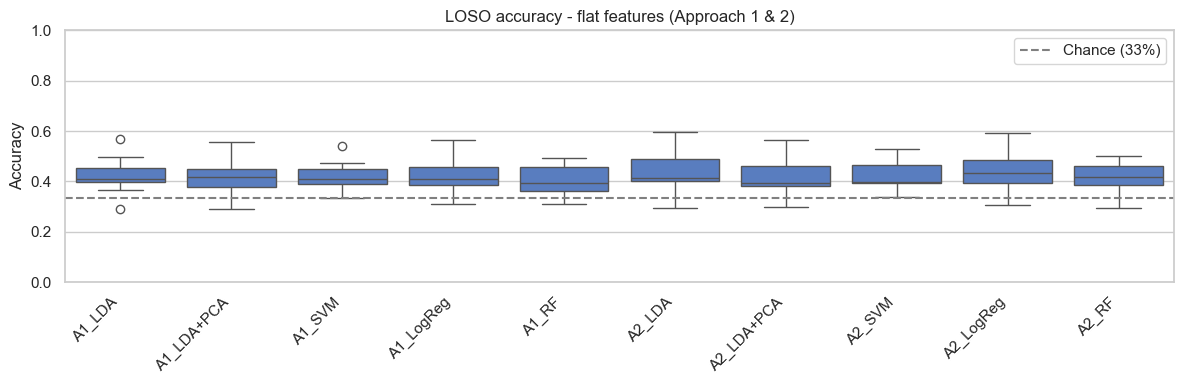

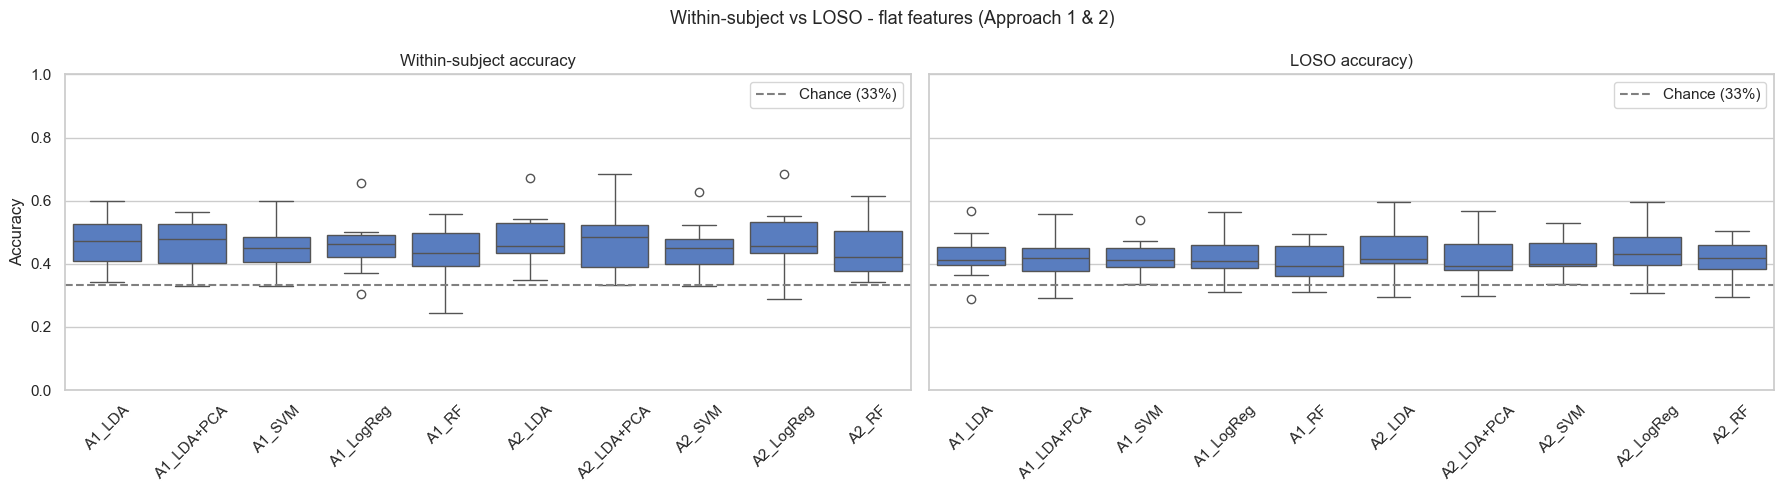

In [8]:
# LOSO boxplot
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=loso_flat_df, x='model', y='accuracy', ax=ax)
ax.axhline(1/3, ls='--', color='gray', label='Chance (33%)')
ax.set_title('LOSO accuracy - flat features (Approach 1 & 2)')
ax.set_xlabel('')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Within-subject vs LOSO Boxplots
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

sns.boxplot(data=ws_flat, x='model', y='accuracy', ax=axes[0])
axes[0].axhline(1/3, ls='--', color='gray', label='Chance (33%)')
axes[0].set_title('Within-subject accuracy')
axes[0].set_xlabel('')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

sns.boxplot(data=loso_flat_df, x='model', y='accuracy', ax=axes[1])
axes[1].axhline(1/3, ls='--', color='gray', label='Chance (33%)')
axes[1].set_title('LOSO accuracy)')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle('Within-subject vs LOSO - flat features (Approach 1 & 2)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. CSP cascade: within-subject and LOSO

Cascade structure:
1. **CSP1**: rest vs movement (binary)
2. **CSP2**: left vs right (binary, applied only to movement trials)

Both steps are trained independently, then chained at inference time.

In [9]:
def run_csp_cascade(X, y, groups, strategy='within', tag=''):

    X = normalise_csp(X)
    records = []

    models_csp = build_models_csp(n_comp=min(8, X.shape[1]*2))

    if strategy == 'within':
        splits = []
        for subj in np.unique(groups):
            idx = np.where(groups == subj)[0]
            tr, te = train_test_split(idx, test_size=0.2,
                                      stratify=y[idx],
                                      random_state=RANDOM_STATE)
            splits.append((subj, tr, te))

    else:  # loso
        logo   = LeaveOneGroupOut()
        splits = [(groups[te][0], tr, te)
                  for tr, te in logo.split(X, y, groups)]

    for left_out, train_idx, test_idx in splits:
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # CSP1: rest (0) vs movement (-1, 1)
        y_csp1_tr = (y_tr != 0).astype(int)
        y_csp1_te = (y_te != 0).astype(int)

        best_acc_csp1, best_model_csp1 = -1, None
        for name, model in models_csp.items():
            m = copy.deepcopy(model)
            m.fit(X_tr, y_csp1_tr)
            acc = accuracy_score(y_csp1_te, m.predict(X_te))
            records.append({'subject': left_out, 'model': f'{tag}_{name}','step': 'CSP1_rest_vs_move', 'accuracy': acc})
            if acc > best_acc_csp1:
                best_acc_csp1   = acc
                best_model_csp1 = m

        # CSP2: left (-1) vs right (1)
        move_tr = y_tr != 0
        move_te = y_te != 0

        y_csp2_tr = (y_tr[move_tr] == 1).astype(int)
        y_csp2_te = (y_te[move_te] == 1).astype(int)

        best_acc_csp2, best_model_csp2 = -1, None
        for name, model in models_csp.items():
            m = copy.deepcopy(model)
            m.fit(X_tr[move_tr], y_csp2_tr)
            acc = accuracy_score(y_csp2_te, m.predict(X_te[move_te]))
            records.append({'subject': left_out, 'model': f'{tag}_{name}',
                            'step': 'CSP2_left_vs_right', 'accuracy': acc})
            if acc > best_acc_csp2:
                best_acc_csp2   = acc
                best_model_csp2 = m

        # Cascade (CSP1 and CSP2)
        y_pred_cascade = np.zeros(len(y_te))
        for i in range(len(X_te)):
            x_i = X_te[i:i+1]
            if best_model_csp1.predict(x_i)[0] == 0:
                y_pred_cascade[i] = 0  
            else:
                lr = best_model_csp2.predict(x_i)[0]
                y_pred_cascade[i] = 1 if lr == 1 else -1

        acc_cascade = accuracy_score(y_te, y_pred_cascade)
        records.append({'subject': left_out, 'model': f'{tag}_cascade','step': 'cascade_3class', 'accuracy': acc_cascade})

    return records

In [10]:
# CSP configurations to evaluate
csp_configs = {
    '3ch_base':   X_3ch,
    '8ch_base':   X_8ch,
    '3ch_mu':     X_3ch_mu,
    '3ch_beta':   X_3ch_beta,
    '8ch_mu':     X_8ch_mu,
    '8ch_beta':   X_8ch_beta,
    '3ch_mubeta': X_3ch_mubeta,
    '8ch_mubeta': X_8ch_mubeta,
}

csp_records_ws   = []
csp_records_loso = []

for cfg_name, X_cfg in csp_configs.items():
    print(f'CSP within-subject: {cfg_name}')
    csp_records_ws += run_csp_cascade(X_cfg, y_csp, groups_csp,
                                       strategy='within', tag=cfg_name)
    print(f'CSP LOSO: {cfg_name}')
    csp_records_loso += run_csp_cascade(X_cfg, y_csp, groups_csp,
                                        strategy='loso', tag=cfg_name)

csp_ws_df   = pd.DataFrame(csp_records_ws)
csp_loso_df = pd.DataFrame(csp_records_loso)

# Summary: cascade only
cascade_ws   = csp_ws_df[csp_ws_df['step'] == 'cascade_3class']
cascade_loso = csp_loso_df[csp_loso_df['step'] == 'cascade_3class']

print('\nCSP cascade within-subject (mean ± std):')
print(cascade_ws.groupby('model')['accuracy'].agg(['mean','std']).round(3))

print('\nCSP cascade LOSO (mean ± std):')
print(cascade_loso.groupby('model')['accuracy'].agg(['mean','std']).round(3))

CSP within-subject: 3ch_base
Computing rank from data with rank=None
    Using tolerance 0.2 (2.2e-16 eps * 3 dim * 3e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.2 (2.2e-16 eps * 3 dim * 3e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.2 (2.2e-16 eps * 3 dim * 3e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LE

C:\Users\ferna\anaconda3\envs\data_analysis\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=4 is greater than n_features=3. All the features will be returned.
  warnings.warn(


Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.17 (2.2e-16 eps * 3 dim * 2.5e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.17 (2.2e-16 eps * 3 dim * 2.5e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.2 (2.2e-16 eps * 3 dim * 3e+14  max singular value)


C:\Users\ferna\anaconda3\envs\data_analysis\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=4 is greater than n_features=3. All the features will be returned.
  warnings.warn(


    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.2 (2.2e-16 eps * 3 dim * 3e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.2 (2.2e-16 eps * 3 dim * 3e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.2 (2.2e-16 

...

Computing rank from data with rank=None
    Using tolerance 0.69 (2.2e-16 eps * 3 dim * 1e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.69 (2.2e-16 eps * 3 dim * 1e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.69 (2.2e-16 eps * 3 dim * 1e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating

C:\Users\ferna\anaconda3\envs\data_analysis\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=4 is greater than n_features=3. All the features will be returned.
  warnings.warn(


Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.57 (2.2e-16 eps * 3 dim * 8.6e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.57 (2.2e-16 eps * 3 dim * 8.6e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.57 (2.2e-16 eps * 3 dim * 8.6e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Esti

C:\Users\ferna\anaconda3\envs\data_analysis\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=4 is greater than n_features=3. All the features will be returned.
  warnings.warn(


CSP within-subject: 8ch_mu
Computing rank from data with rank=None
    Using tolerance 0.78 (2.2e-16 eps * 8 dim * 4.4e+14  max singular value)
    Estimated rank (data): 8
    data: rank 8 computed from 8 data channels with 0 projectors
Reducing data rank from 8 -> 8
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.78 (2.2e-16 eps * 8 dim * 4.4e+14  max singular value)
    Estimated rank (data): 8
    data: rank 8 computed from 8 data channels with 0 projectors
Reducing data rank from 8 -> 8
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 0.78 (2.2e-16 eps * 8 dim * 4.4e+14  max singular value)
    Estimated rank (data): 8
    data: rank 8 computed from 8 data channels with 0 projectors
Reducing data rank from 8 -> 8
Estimating class=0 covariance u

C:\Users\ferna\AppData\Local\Temp\ipykernel_10648\77717246.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(means.index, rotation=45, ha='right')
C:\Users\ferna\AppData\Local\Temp\ipykernel_10648\77717246.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(means.index, rotation=45, ha='right')


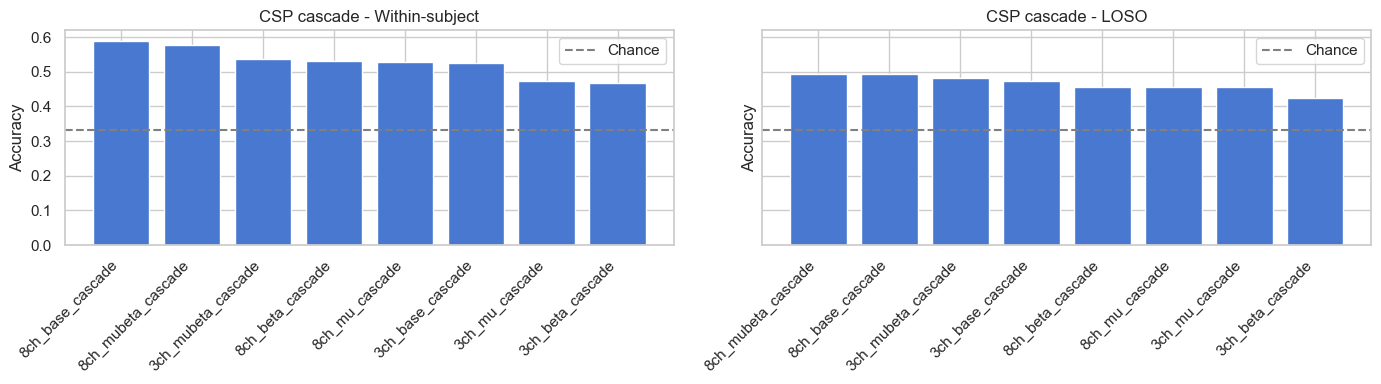

In [28]:
# CSP cascade comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, df_plot, title in zip(
    axes,
    [cascade_ws, cascade_loso],
    ['Within-subject', 'LOSO']
):
    means = df_plot[df_plot['step'] == 'cascade_3class'].groupby('model')['accuracy'].mean().sort_values(ascending=False)
    ax.bar(means.index, means.values)
    ax.axhline(1/3, ls='--', color='gray', label='Chance')
    ax.set_title(f'CSP cascade - {title}')
    ax.set_ylabel('Accuracy')
    ax.set_xticklabels(means.index, rotation=45, ha='right')
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Within vs LOSO comparison (all models)

In [29]:
# Build summary table: best model per family
def summary_row(df_ws, df_loso, label):
    if df_ws.empty or df_loso.empty:
        return None
    best_ws   = df_ws.groupby('model')['accuracy'].mean().idxmax()
    best_loso = df_loso.groupby('model')['accuracy'].mean().idxmax()
    return {
        'Pipeline': label,
        'Best model (within)': best_ws,
        'Within acc (mean+/-std)': f"{df_ws[df_ws['model']==best_ws]['accuracy'].mean():.3f} "
                                  f"± {df_ws[df_ws['model']==best_ws]['accuracy'].std():.3f}",
        'Best model (LOSO)': best_loso,
        'LOSO acc (mean+/-std)': f"{df_loso[df_loso['model']==best_loso]['accuracy'].mean():.3f} "
                                f"± {df_loso[df_loso['model']==best_loso]['accuracy'].std():.3f}",
    }

summary_rows = [
    summary_row(ws_flat[ws_flat['model'].str.startswith('A1_')],
                loso_flat_df[loso_flat_df['model'].str.startswith('A1_')],
                'Approach 1 (ERD C3+Cz+C4 + MRCP Cz+Fz)'),
    summary_row(ws_flat[ws_flat['model'].str.startswith('A2_')],
                loso_flat_df[loso_flat_df['model'].str.startswith('A2_')],
                'Approach 2 (ERD C3+Cz+C4 + MRCP C3+Cz+C4+Fz)'),
    summary_row(cascade_ws[cascade_ws['step'] == 'cascade_3class'],
                cascade_loso[cascade_loso['step'] == 'cascade_3class'],
                'CSP cascade (best config)'),
]

summary_df = pd.DataFrame([r for r in summary_rows if r is not None])
print('\n SUMMARY TABLE\n')
print(summary_df.to_string(index=False))


 SUMMARY TABLE

                                    Pipeline Best model (within) Within acc (mean+/-std)  Best model (LOSO) LOSO acc (mean+/-std)
      Approach 1 (ERD C3+Cz+C4 + MRCP Cz+Fz)              A1_LDA           0.466 ± 0.084          A1_LogReg         0.426 ± 0.074
Approach 2 (ERD C3+Cz+C4 + MRCP C3+Cz+C4+Fz)           A2_LogReg           0.484 ± 0.099             A2_LDA         0.445 ± 0.085
                   CSP cascade (best config)    8ch_base_cascade           0.590 ± 0.089 8ch_mubeta_cascade         0.494 ± 0.089


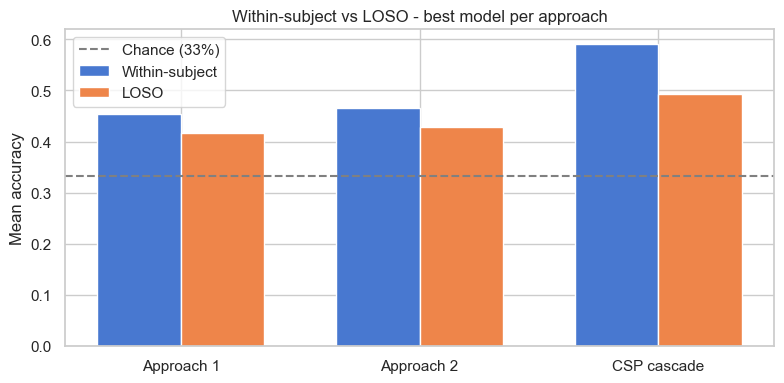

In [30]:
# Within vs LOSO bar chart (best model for each approach)
families = ['Approach 1', 'Approach 2', 'CSP cascade']

ws_means = [
    ws_flat[ws_flat['model'].str.startswith('A1_')]['accuracy'].mean(),
    ws_flat[ws_flat['model'].str.startswith('A2_')]['accuracy'].mean(),
    cascade_ws[
        (cascade_ws['step'] == 'cascade_3class') &
        (cascade_ws['model'] == best_csp_within)   #  only el best within
    ]['accuracy'].mean(),
]

loso_means = [
    loso_flat_df[loso_flat_df['model'].str.startswith('A1_')]['accuracy'].mean(),
    loso_flat_df[loso_flat_df['model'].str.startswith('A2_')]['accuracy'].mean(),
    cascade_loso[
        (cascade_loso['step'] == 'cascade_3class') &
        (cascade_loso['model'] == best_csp_loso)   #  only best LOSO
    ]['accuracy'].mean(),
]

x = np.arange(len(families))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, ws_means, width, label='Within-subject')
ax.bar(x + width/2, loso_means, width, label='LOSO')
ax.axhline(1/3, ls='--', color='gray', label='Chance (33%)')
ax.set_xticks(x)
ax.set_xticklabels(families)
ax.set_ylabel('Mean accuracy')
ax.set_title('Within-subject vs LOSO - best model per approach')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Best model: detailed evaluation

Select the best overall model and show: confusion matrix, per-class metrics, per-subject accuracy.

In [31]:
# Identify best model (highest LOSO accuracy)
# Combine all LOSO results
all_loso = pd.concat([
    loso_flat_df,
    cascade_loso[cascade_loso['step'] == 'cascade_3class'][['subject','model','accuracy']]
], ignore_index=True)

# Best within CSP model
best_csp_within = cascade_ws[cascade_ws['step']=='cascade_3class'].groupby('model')['accuracy'].mean().idxmax()
best_csp_loso   = cascade_loso[cascade_loso['step']=='cascade_3class'].groupby('model')['accuracy'].mean().idxmax()

# Extract config name (remove _cascade suffix)
cfg_within = best_csp_within.replace('_cascade','')
cfg_loso   = best_csp_loso.replace('_cascade','')

print(f'\nMost frequent classifier per step - Within-subject ({best_csp_within}):')
for step in ['CSP1_rest_vs_move', 'CSP2_left_vs_right']:
    step_df = csp_ws_df[
        (csp_ws_df['model'].str.contains(cfg_within)) &
        (csp_ws_df['step'] == step)
    ]
    if not step_df.empty:
        best_per_fold = step_df.loc[step_df.groupby('subject')['accuracy'].idxmax()]
        most_common   = best_per_fold['model'].value_counts().idxmax()
        count         = best_per_fold['model'].value_counts().max()
        mean_acc      = step_df.groupby('model')['accuracy'].mean().max()
        print(f'  {step}: {most_common} (selected in {count}/11 folds, mean acc = {mean_acc:.3f})')

print(f'\nMost frequent classifier per step - LOSO ({best_csp_loso}):')
for step in ['CSP1_rest_vs_move', 'CSP2_left_vs_right']:
    step_df = csp_loso_df[
        (csp_loso_df['model'].str.contains(cfg_loso)) &
        (csp_loso_df['step'] == step)
    ]
    if not step_df.empty:
        best_per_fold = step_df.loc[step_df.groupby('subject')['accuracy'].idxmax()]
        most_common   = best_per_fold['model'].value_counts().idxmax()
        count         = best_per_fold['model'].value_counts().max()
        mean_acc      = step_df.groupby('model')['accuracy'].mean().max()
        print(f'  {step}: {most_common} (selected in {count}/11 folds, mean acc = {mean_acc:.3f})')


Most frequent classifier per step - Within-subject (8ch_base_cascade):
  CSP1_rest_vs_move: 8ch_base_CSP+LDA (selected in 7/11 folds, mean acc = 0.745)
  CSP2_left_vs_right: 8ch_base_CSP+LogReg (selected in 5/11 folds, mean acc = 0.707)

Most frequent classifier per step - LOSO (8ch_mubeta_cascade):
  CSP1_rest_vs_move: 8ch_mubeta_CSP+LDA+FS (selected in 6/11 folds, mean acc = 0.700)
  CSP2_left_vs_right: 8ch_mubeta_CSP+LDA (selected in 5/11 folds, mean acc = 0.620)


In [32]:
# Re-run best LOSO model with full predictions for confusion matrix

X_best = normalise_csp(X_8ch_mubeta) # Best LOSO: 8ch_mubeta_cascade
logo = LeaveOneGroupOut()
models_csp = build_models_csp(n_comp=8)

all_y_true = []
all_y_pred = []

splits = [(groups_csp[te][0], tr, te)
          for tr, te in logo.split(X_best, y_csp, groups_csp)]

for left_out, train_idx, test_idx in splits:
    X_tr, X_te = X_best[train_idx], X_best[test_idx]
    y_tr, y_te = y_csp[train_idx],  y_csp[test_idx]

    # CSP1: rest vs movement
    y_csp1_tr = (y_tr != 0).astype(int)
    best_acc_csp1, best_model_csp1 = -1, None
    for name, model in models_csp.items():
        m = copy.deepcopy(model)
        m.fit(X_tr, y_csp1_tr)
        acc = accuracy_score((y_te != 0).astype(int), m.predict(X_te))
        if acc > best_acc_csp1:
            best_acc_csp1   = acc
            best_model_csp1 = m

    # CSP2: left vs right (movement trials only)
    move_tr = y_tr != 0
    move_te = y_te != 0
    if move_tr.sum() < 4 or move_te.sum() < 2:
        continue

    y_csp2_tr = (y_tr[move_tr] == 1).astype(int)
    best_acc_csp2, best_model_csp2 = -1, None
    for name, model in models_csp.items():
        m = copy.deepcopy(model)
        m.fit(X_tr[move_tr], y_csp2_tr)
        acc = accuracy_score((y_te[move_te] == 1).astype(int), m.predict(X_te[move_te]))
        if acc > best_acc_csp2:
            best_acc_csp2   = acc
            best_model_csp2 = m

    # Cascade inference trial by trial
    y_pred_fold = np.zeros(len(y_te))
    for i in range(len(X_te)):
        x_i = X_te[i:i+1]
        if best_model_csp1.predict(x_i)[0] == 0:
            y_pred_fold[i] = 0
        else:
            lr = best_model_csp2.predict(x_i)[0]
            y_pred_fold[i] = 1 if lr == 1 else -1

    all_y_true.extend(y_te.tolist())
    all_y_pred.extend(y_pred_fold.tolist())

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

# Map numeric labels to strings for readable report
label_map = {-1: 'left', 0: 'rest', 1: 'right'}
y_true_str = [label_map[v] for v in all_y_true]
y_pred_str = [label_map[v] for v in all_y_pred]

print(f'\nClassification report: 8ch_mubeta_cascade (LOSO):')
print(classification_report(y_true_str, y_pred_str, target_names=['left','rest','right']))

Computing rank from data with rank=None
    Using tolerance 5.7 (2.2e-16 eps * 16 dim * 1.6e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 5.7 (2.2e-16 eps * 16 dim * 1.6e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 5.7 (2.2e-16 eps * 16 dim * 1.6e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=0 covariance using LEDOIT_

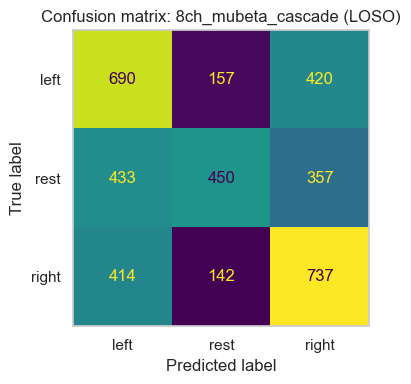

In [33]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_true_str, y_pred_str,
    display_labels=['left','rest','right'],
    ax=ax, colorbar=False
)
ax.grid(False)
ax.set_title('Confusion matrix: 8ch_mubeta_cascade (LOSO)')
plt.tight_layout()
plt.show()


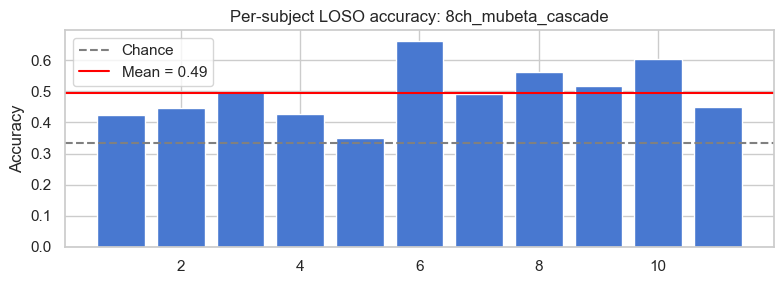

In [34]:
# Per-subject LOSO accuracy
best_loso_persubj = best_df.set_index('subject')['accuracy'].sort_index()

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(best_loso_persubj.index, best_loso_persubj.values)
ax.axhline(1/3, ls='--', color='gray', label='Chance')
ax.axhline(best_loso_persubj.mean(), ls='-', color='red',
           label=f'Mean = {best_loso_persubj.mean():.2f}')
ax.set_ylabel('Accuracy')
ax.set_title(f'Per-subject LOSO accuracy: {best_row}')
ax.legend()
plt.tight_layout()
plt.show()

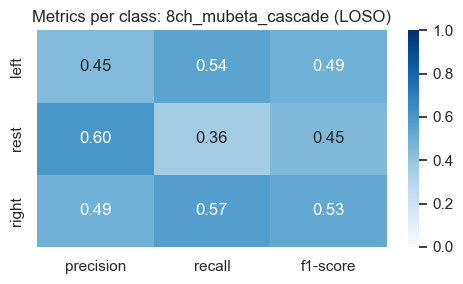

In [35]:
# Per-class F1 heatmap
report_dict = classification_report(
    y_true_str, y_pred_str,
    target_names=['left','rest','right'], output_dict=True
)
metrics_df = pd.DataFrame(report_dict).T.loc[['left','rest','right'],
                          ['precision','recall','f1-score']]

fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(metrics_df, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, ax=ax)
ax.set_title('Metrics per class: 8ch_mubeta_cascade (LOSO)')
plt.tight_layout()
plt.show()

## 8. Algorithmic latency

Formula from project guidelines:  
**Total Latency = t_window + t_preprocessing + t_inference**

In [36]:
# t_window: determined by the longest window needed
# ERD window: 0.5 s to 1.5 s post-onset, must wait 1.5 s after onset
# MRCP window: -0.5 s to +0.5 s around onset, only needs 0.5 s post-onset
# Bottleneck is ERD window: 1.5 s
t_window = 1.5

# t_preprocessing: normalise_csp on 1 trial
x_single = X_best[0:1]
N = 1000
t0 = time.perf_counter()
for _ in range(N):
    normalise_csp(x_single)
t_preprocessing = (time.perf_counter() - t0) / N

# t_inference: CSP1 predict on 1 trial
t0 = time.perf_counter()
for _ in range(N):
    best_model_csp1.predict(x_single)
t_inference = (time.perf_counter() - t0) / N

t_total = t_window + t_preprocessing + t_inference

print(f't_window (ERD): {t_window*1000:.1f} ms (bottleneck)')
print(f't_window (MRCP): 500.0 ms  (no bottleneck, -0.5 to +0.5 s)')
print(f't_preprocessing: {t_preprocessing*1000:.3f} ms')
print(f't_inference: {t_inference*1000:.3f} ms')
print(f'Total latency: {t_total*1000:.1f} ms')
print(f'Real-time BCI suitable (< 500 ms): {"Yes" if t_total < 0.5 else "No - window dominates (Bottleneck)"}')

t_window (ERD): 1500.0 ms (bottleneck)
t_window (MRCP): 500.0 ms  (no bottleneck, -0.5 to +0.5 s)
t_preprocessing: 0.199 ms
t_inference: 1.684 ms
Total latency: 1501.9 ms
Real-time BCI suitable (< 500 ms): No - window dominates (Bottleneck)


## 9. Export results

In [23]:
# All LOSO results
all_loso.to_csv('results_loso_all.csv', index=False, sep=';')

# All within-subject results
pd.concat([ws_flat, csp_ws_df[['subject','model','accuracy']]], ignore_index=True) \
  .to_csv('results_within_all.csv', index=False, sep=';')

# Summary table
summary_df.to_csv('results_summary.csv', index=False, sep=';')